In [1]:
import nltk
from nltk.corpus import treebank
import statistics
import matplotlib.pyplot as plt
import numpy as np
import re

# Download and load corpus
nltk.download('treebank')
sentences = treebank.sents()
words = treebank.words()
tagged_words = treebank.tagged_words()

# Remove trace tokens and empty categories
TRACE_TOKEN_PATTERN = re.compile(r'^\*.*\*$|^\*$|^\*-?\d+$|^0$')
def is_valid_token(word, pos_tag=None):
    if pos_tag == '-NONE-':
        return False
    if TRACE_TOKEN_PATTERN.match(word):
        return False
    return True

# Cleaned sentences as strings
cleaned_sentences = []
for sentence in treebank.tagged_sents():
    cleaned_tokens = [word for word, pos in sentence if is_valid_token(word, pos)]
    if cleaned_tokens:
        cleaned_sentences.append(" ".join(cleaned_tokens))

# --- Remove outliers based on sentence length ---
sentence_lengths = [len(sentence.split()) for sentence in cleaned_sentences]
Q1 = np.percentile(sentence_lengths, 25)
Q3 = np.percentile(sentence_lengths, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

filtered_cleaned_sentences = [
    sentence for sentence in cleaned_sentences
    if lower_bound <= len(sentence.split()) <= upper_bound
]

# Gather statistics on the filtered cleaned data
filtered_total_sentences = len(filtered_cleaned_sentences)
filtered_all_tokens = [token for sentence in filtered_cleaned_sentences for token in sentence.split()]
filtered_total_tokens = len(filtered_all_tokens)
filtered_unique_tokens = set(filtered_all_tokens)
filtered_total_unique_tokens = len(filtered_unique_tokens)

# Sentence length statistics
filtered_sentence_lengths = [len(sentence.split()) for sentence in filtered_cleaned_sentences]
if len(filtered_sentence_lengths) > 1:
    filtered_variance_sentence_length = round(statistics.pvariance(filtered_sentence_lengths), 3)
    filtered_std_dev_sentence_length = round(statistics.stdev(filtered_sentence_lengths), 3)
else:
    filtered_variance_sentence_length = 0
    filtered_std_dev_sentence_length = 0

# Average sentence length
filtered_average_sentence_length = round(filtered_total_tokens / filtered_total_sentences if filtered_total_sentences else 0, 3)

print(f"Original sentences: {len(cleaned_sentences)}")
print("\n--- Statistics for Filtered Cleaned Data ---")
print("Total number of sentences:", filtered_total_sentences)
print("Total number of words:", filtered_total_tokens)
print("Total number of unique words:", filtered_total_unique_tokens)
print("Average sentence length:", filtered_average_sentence_length)
print("Variance of sentence lengths:", filtered_variance_sentence_length)
print("Standard deviation of sentence lengths:", filtered_std_dev_sentence_length)

[nltk_data] Downloading package treebank to
[nltk_data]     /Users/larsheijnen/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


Original sentences: 3914

--- Statistics for Filtered Cleaned Data ---
Total number of sentences: 3868
Total number of words: 90895
Total number of unique words: 11647
Average sentence length: 23.499
Variance of sentence lengths: 106.825
Standard deviation of sentence lengths: 10.337


In [2]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embeddings_no_padding(texts):
    # Determine optimal device for Apple Silicon
    device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Set model to device and evaluation mode only once
    model.to(device)
    model.eval()
    
    # Preallocate output array for better memory efficiency
    embeddings = np.zeros((len(texts), model.config.hidden_size), dtype=np.float32)
    
    with torch.no_grad():  # Disable gradient calculation for inference
        # Process texts in small batches for better memory management
        batch_size = 32
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            batch_embeddings = []
            
            # Process each text individually to match original behavior
            for j, text in enumerate(batch_texts):
                # Keep padding=False to match original exactly
                inputs = tokenizer(text, padding=False, truncation=True, return_tensors='pt').to(device)
                outputs = model(**inputs)
                emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                batch_embeddings.append(emb[0])
                
                # Free memory for individual processing
                del inputs, outputs
            
            # Update embeddings array
            embeddings[i:i+len(batch_texts)] = np.array(batch_embeddings)
            
            # Free memory explicitly after batch
            del batch_embeddings
            if device == 'mps' or device == 'cuda':
                torch.mps.empty_cache() if device == 'mps' else torch.cuda.empty_cache()
                
    return embeddings


print("Generating BERT embeddings for filtered_cleaned_sentences (preprocessed, outliers removed)...")
X_sentence_features = get_bert_embeddings_no_padding(filtered_cleaned_sentences)
print(f"Sentence BERT embeddings shape: {X_sentence_features.shape}")

get_bert_embeddings_no_padding([filtered_cleaned_sentences[0]])

Generating BERT embeddings for filtered_cleaned_sentences (preprocessed, outliers removed)...
Sentence BERT embeddings shape: (3868, 768)


array([[-4.86198276e-01,  2.93048412e-01,  3.75086993e-01,
        -3.84702384e-01, -1.77396685e-01, -5.29885292e-01,
         2.53705710e-01,  1.26502588e-01,  2.33976215e-01,
        -3.91963989e-01, -5.74748039e-01,  2.37874240e-02,
        -4.53744009e-02,  3.44385266e-01,  1.59705445e-01,
        -6.53184354e-02, -2.21710816e-01,  5.44918716e-01,
         2.04050243e-01, -3.10351998e-01, -2.53553241e-01,
        -6.99147046e-01,  6.85002208e-01,  8.21404979e-02,
        -1.12280577e-01, -2.87439346e-01, -1.02868676e-01,
        -3.81908268e-01, -4.05884564e-01, -5.37281573e-01,
         5.60068004e-02,  3.03228259e-01, -4.29823369e-01,
        -1.67788029e-01,  5.25796890e-01,  2.30641589e-01,
         5.94016373e-01, -3.33054066e-02,  2.52491176e-01,
         4.57178175e-01, -5.46683632e-02,  2.79393673e-01,
         5.22458196e-01, -4.93322819e-01, -1.40231624e-01,
        -5.15283465e-01, -2.63092327e+00, -1.74056724e-01,
        -1.22571692e-01, -1.94148242e-01,  1.66194677e-0

In [3]:
import csv

# Define the output CSV filename
csv_filename = "sentence_embeddings_and_lengths.csv"

# Get the dimensionality of the embeddings
embedding_dim = X_sentence_features.shape[1]

# Create the header row
header = [f'embedding_{i}' for i in range(embedding_dim)] + ['sentence_length']

# Write data to CSV
with open(csv_filename, 'w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile)
    csv_writer.writerow(header)
    
    for i in range(len(filtered_cleaned_sentences)):
        embedding = X_sentence_features[i].tolist()  # Convert numpy array to list
        length = filtered_sentence_lengths[i]
        row = embedding + [length]
        csv_writer.writerow(row)

print(f"\nSuccessfully created {csv_filename} with embeddings and sentence lengths.")
print(f"CSV file has {len(filtered_cleaned_sentences)} data rows (excluding header).")


Successfully created sentence_embeddings_and_lengths.csv with embeddings and sentence lengths.
CSV file has 3868 data rows (excluding header).


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
    max_error,
    median_absolute_error
)
import numpy as np

# Target: sentence lengths
y = [len(sentence.split()) for sentence in filtered_cleaned_sentences]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_sentence_features, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on test set
y_pred = lr.predict(X_test)

# Evaluate the model with multiple metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
explained_var = explained_variance_score(y_test, y_pred)
max_err = max_error(y_test, y_pred)

print(f"Test MSE: {mse:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test MAE: {mae:.3f}")
print(f"Test Median AE: {medae:.3f}")
print(f"Test Max Error: {max_err:.3f}")
print(f"Test R^2: {r2:.3f}")
print(f"Test Explained Variance: {explained_var:.3f}")

Test MSE: 18.289
Test RMSE: 4.277
Test MAE: 3.302
Test Median AE: 2.635
Test Max Error: 17.890
Test R^2: 0.837
Test Explained Variance: 0.838


Finding optimal number of clusters...


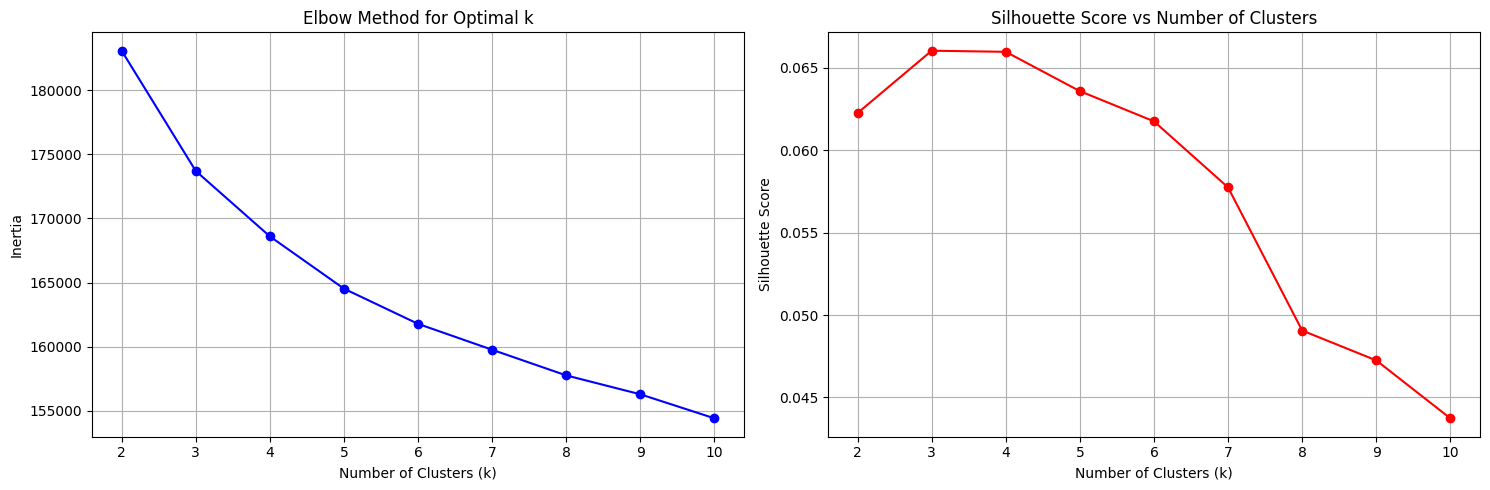

Best k based on silhouette score: 3
Silhouette scores: {2: np.float32(0.06226123), 3: np.float32(0.06604637), 4: np.float32(0.06597969), 5: np.float32(0.063593626), 6: np.float32(0.06176043), 7: np.float32(0.057749774), 8: np.float32(0.04906364), 9: np.float32(0.047251277), 10: np.float32(0.043734044)}


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Function to help determine the optimal number of clusters for KMeans
def find_optimal_clusters(X, max_k=10):
    """
    Use the elbow method and silhouette score to help pick the best k for KMeans.
    Plots both metrics for visual inspection.
    """
    inertias = []  # List to store inertia values for each k
    silhouette_scores = []  # List to store silhouette scores for each k
    K_range = range(2, max_k + 1)  # Start at 2 clusters (can't do silhouette for k=1)
    
    for k in K_range:
        # Fit KMeans for current k
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        # Inertia/WCSS: sum of squared distances to closest cluster center
        inertias.append(kmeans.inertia_)
        # Silhouette score: how well samples are clustered (higher is better)
        silhouette_scores.append(silhouette_score(X, kmeans.labels_))
    
    # Plot the elbow curve (inertia) and silhouette scores for each k
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Elbow plot: look for the "elbow" where inertia stops decreasing sharply
    ax1.plot(K_range, inertias, 'bo-')
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia')
    ax1.set_title('Elbow Method for Optimal k')
    ax1.grid(True)
    
    # Silhouette score plot: higher values indicate better-defined clusters
    ax2.plot(K_range, silhouette_scores, 'ro-')
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title('Silhouette Score vs Number of Clusters')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Pick the k with the highest silhouette score
    best_k = K_range[np.argmax(silhouette_scores)]
    print(f"Best k based on silhouette score: {best_k}")
    print(f"Silhouette scores: {dict(zip(K_range, silhouette_scores))}")
    
    return best_k, silhouette_scores

# Actually run the function to find the optimal number of clusters for our data
print("Finding optimal number of clusters...")
optimal_k, silhouette_scores = find_optimal_clusters(X_sentence_features, max_k=10)


K-MEANS CLUSTERING WITH K=3
Silhouette Score: 0.066

Cluster Statistics:
         count   mean    std  min  max  median
cluster                                       
0         1604  19.69   9.87    1   53    19.0
1          494  26.00  10.59    4   53    25.0
2         1770  26.25   9.57    2   53    25.0

Cluster Separation Analysis:
Cluster 0: 1604 sentences, avg length: 19.7 ± 9.9
Cluster 1: 494 sentences, avg length: 26.0 ± 10.6
Cluster 2: 1770 sentences, avg length: 26.3 ± 9.6


/var/folders/kw/d3zgy6jx0gl0lybbg494yl8c0000gn/T/ipykernel_54077/1075060775.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cluster_data, labels=[f'C{i}' for i in sorted(df_results['cluster'].unique())])


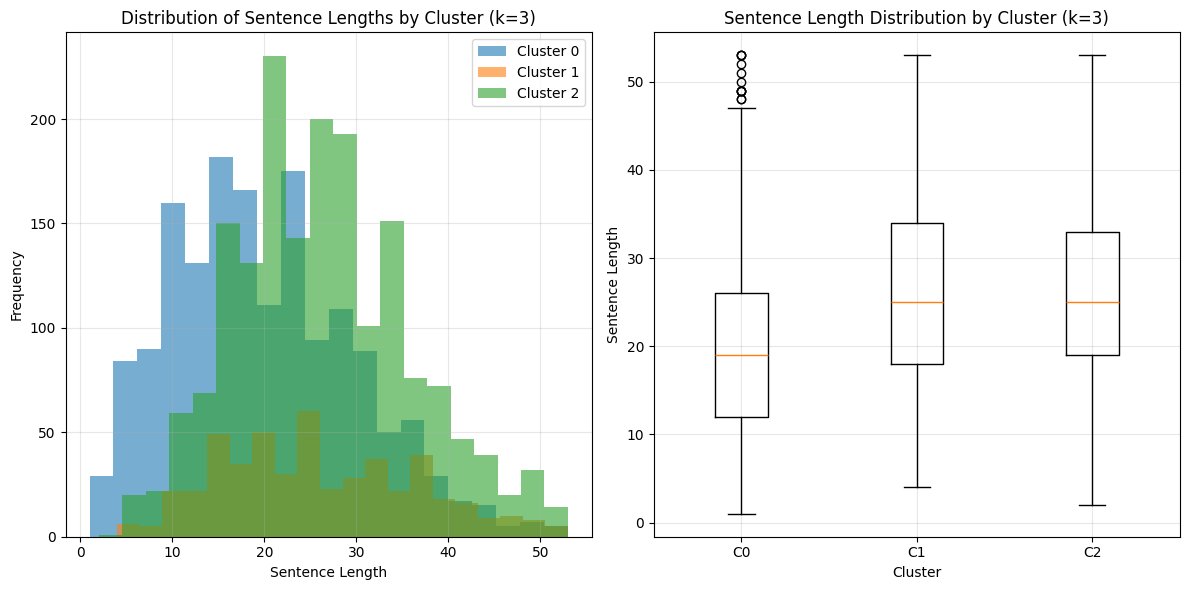


K-MEANS CLUSTERING WITH K=5
Silhouette Score: 0.064

Cluster Statistics:
         count   mean    std  min  max  median
cluster                                       
0          485  25.95  10.59    4   53    25.0
1         1146  18.48   9.86    1   53    17.0
2          618  21.46   9.42    2   53    20.0
3         1011  27.48   9.11    8   53    27.0
4          608  26.45   9.38    3   53    25.0

Cluster Separation Analysis:
Cluster 0: 485 sentences, avg length: 26.0 ± 10.6
Cluster 1: 1146 sentences, avg length: 18.5 ± 9.9
Cluster 2: 618 sentences, avg length: 21.5 ± 9.4
Cluster 3: 1011 sentences, avg length: 27.5 ± 9.1
Cluster 4: 608 sentences, avg length: 26.5 ± 9.4


/var/folders/kw/d3zgy6jx0gl0lybbg494yl8c0000gn/T/ipykernel_54077/1075060775.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cluster_data, labels=[f'C{i}' for i in sorted(df_results['cluster'].unique())])


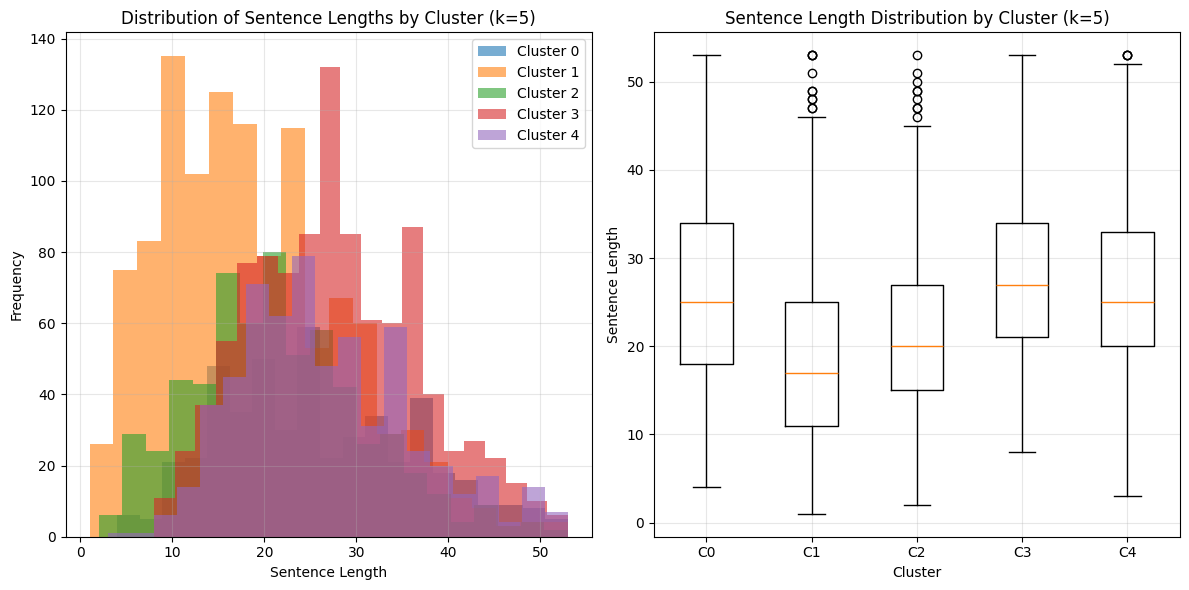


K-MEANS CLUSTERING WITH K=7
Silhouette Score: 0.058

Cluster Statistics:
         count   mean    std  min  max  median
cluster                                       
0          461  25.52  10.41    4   53    24.0
1          596  26.55   9.13    8   53    26.0
2          461  26.35   9.29    7   53    25.0
3         1003  17.97   9.91    1   53    16.0
4          553  28.56   9.36    9   53    28.0
5          391  20.65   8.67    2   46    20.0
6          403  23.01   9.83    2   51    22.0

Cluster Separation Analysis:
Cluster 0: 461 sentences, avg length: 25.5 ± 10.4
Cluster 1: 596 sentences, avg length: 26.5 ± 9.1
Cluster 2: 461 sentences, avg length: 26.3 ± 9.3
Cluster 3: 1003 sentences, avg length: 18.0 ± 9.9
Cluster 4: 553 sentences, avg length: 28.6 ± 9.4
Cluster 5: 391 sentences, avg length: 20.6 ± 8.7
Cluster 6: 403 sentences, avg length: 23.0 ± 9.8


/var/folders/kw/d3zgy6jx0gl0lybbg494yl8c0000gn/T/ipykernel_54077/1075060775.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cluster_data, labels=[f'C{i}' for i in sorted(df_results['cluster'].unique())])


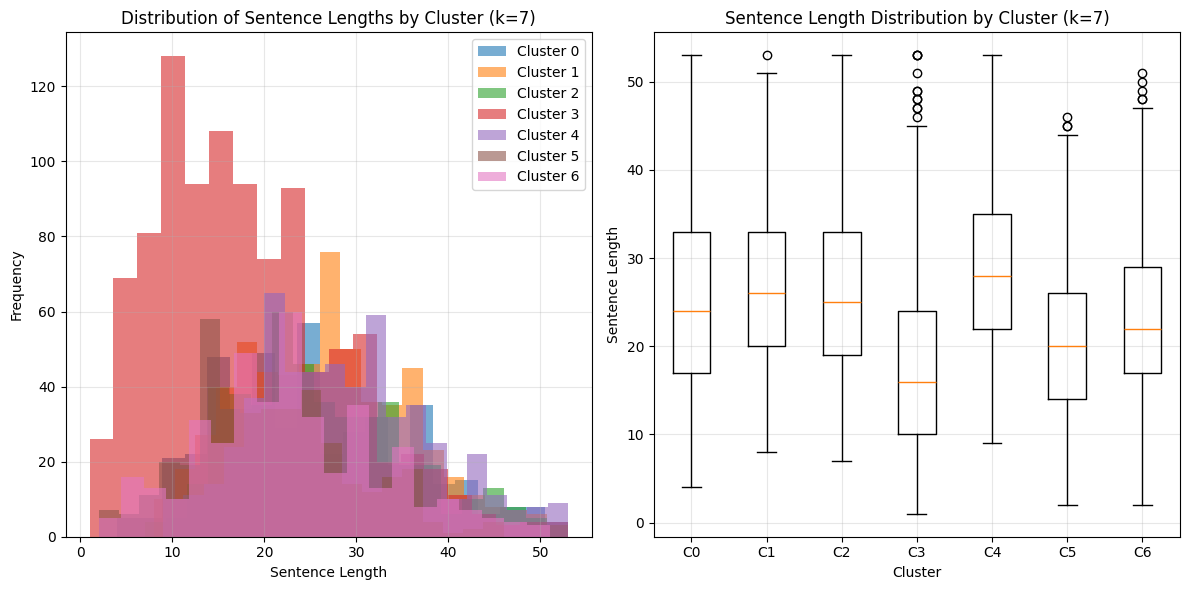

In [5]:
# Run K-means clustering for a range of k values and analyze sentence length patterns
def perform_kmeans_analysis(X, sentences, sentence_lengths, k_values=[3, 5, 7, optimal_k]):
    """Perform K-means clustering and analyze sentence length patterns"""
    
    results = {}  # Store results for each k
    
    for k in k_values:
        print(f"\n{'='*50}")
        print(f"K-MEANS CLUSTERING WITH K={k}")
        print(f"{'='*50}")
        
        # Fit KMeans clustering for current k
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)
        
        # Compute silhouette score for current clustering
        sil_score = silhouette_score(X, cluster_labels)
        print(f"Silhouette Score: {sil_score:.3f}")
        
        # Build a DataFrame to hold sentences, their lengths, and cluster assignments
        df_results = pd.DataFrame({
            'sentence': sentences,
            'sentence_length': sentence_lengths,
            'cluster': cluster_labels
        })
        
        # Compute basic statistics for sentence length within each cluster
        cluster_stats = df_results.groupby('cluster')['sentence_length'].agg([
            'count', 'mean', 'std', 'min', 'max', 'median'
        ]).round(2)
        
        print(f"\nCluster Statistics:")
        print(cluster_stats)
        
        # Print out mean and std of sentence length for each cluster
        print(f"\nCluster Separation Analysis:")
        for cluster_id in sorted(df_results['cluster'].unique()):
            cluster_sentences = df_results[df_results['cluster'] == cluster_id]
            mean_length = cluster_sentences['sentence_length'].mean()
            std_length = cluster_sentences['sentence_length'].std()
            print(f"Cluster {cluster_id}: {len(cluster_sentences)} sentences, "
                  f"avg length: {mean_length:.1f} ± {std_length:.1f}")
        
        # Save all relevant results for this k
        results[k] = {
            'kmeans': kmeans,
            'labels': cluster_labels,
            'silhouette_score': sil_score,
            'cluster_stats': cluster_stats,
            'dataframe': df_results
        }
        
        # Plotting: visualize sentence length distributions for each cluster
        plt.figure(figsize=(12, 6))
        
        # First subplot: histogram of sentence lengths by cluster
        plt.subplot(1, 2, 1)
        for cluster_id in sorted(df_results['cluster'].unique()):
            cluster_lengths = df_results[df_results['cluster'] == cluster_id]['sentence_length']
            plt.hist(cluster_lengths, alpha=0.6, label=f'Cluster {cluster_id}', bins=20)
        plt.xlabel('Sentence Length')
        plt.ylabel('Frequency')
        plt.title(f'Distribution of Sentence Lengths by Cluster (k={k})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Second subplot: boxplot of sentence lengths by cluster
        plt.subplot(1, 2, 2)
        # Prepare data for boxplot: one array per cluster
        cluster_data = [df_results[df_results['cluster'] == i]['sentence_length'].values 
                        for i in sorted(df_results['cluster'].unique())]
        plt.boxplot(cluster_data, labels=[f'C{i}' for i in sorted(df_results['cluster'].unique())])
        plt.xlabel('Cluster')
        plt.ylabel('Sentence Length')
        plt.title(f'Sentence Length Distribution by Cluster (k={k})')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return results

# Choose which k values to test: always 3, 5, 7, and optimal_k (unless optimal_k is already in the list)
k_values_to_test = [3, 5, 7, optimal_k] if optimal_k not in [3, 5, 7] else [3, 5, 7]

# Run the clustering analysis and store results
clustering_results = perform_kmeans_analysis(
    X_sentence_features, 
    filtered_cleaned_sentences, 
    filtered_sentence_lengths,
    k_values_to_test
)